In [6]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Establish secure connection to your local MySQL database
try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="1234",  # <-- Change this to your Workbench password
        database="uganda_emobility"
    )
    print("Successfully connected to uganda_emobility database!")
except Exception as e:
    print(f"Connection failed: {e}")

# 2. Extract vehicle specifications and daily logs using an SQL Join
query = """
SELECT 
    t.date_recorded,
    v.model_name,
    v.vehicle_type,
    v.fuel_type,
    t.distance_km,
    v.efficiency_value,
    v.purchase_price_ugx,
    r.petrol_price_per_liter,
    r.electricity_per_kwh,
    r.grid_emission_factor_g_co2_kwh
FROM daily_trips_log t
JOIN vehicle_specs v ON t.vehicle_id = v.vehicle_id
CROSS JOIN regional_tariffs r;
"""

# Read the database directly into a Pandas DataFrame
df = pd.read_sql(query, conn)
conn.close()

# 3. Feature Engineering: Calculate daily operational expenses (UGX)
def calculate_costs(row):
    if row['fuel_type'] == 'Petrol':
        # Distance divided by KM/L multiplied by Petrol Price
        return (row['distance_km'] / row['efficiency_value']) * row['petrol_price_per_liter']
    else:
        # Distance divided by KM/kWh multiplied by Power Tariff
        return (row['distance_km'] / row['efficiency_value']) * row['electricity_per_kwh']

df['daily_cost_ugx'] = df.apply(calculate_costs, axis=1)

# 4. Feature Engineering: Calculate daily tailpipe + grid emissions (Grams of CO2)
def calculate_emissions(row):
    if row['fuel_type'] == 'Petrol':
        # Burning 1 Liter of Petrol releases ~2,310 grams of CO2
        return (row['distance_km'] / row['efficiency_value']) * 2310
    else:
        # Electric vehicle footprint depends entirely on the grid factor
        return (row['distance_km'] / row['efficiency_value']) * row['grid_emission_factor_g_co2_kwh']

df['daily_co2_grams'] = df.apply(calculate_emissions, axis=1)

# 5. Aggregate results to show average daily differences
summary = df.groupby(['model_name', 'fuel_type'])[['daily_cost_ugx', 'daily_co2_grams']].mean().reset_index()
print("\n--- KAMPALA TRANSIT DAILY MARGINS ---")
print(summary)


Successfully connected to uganda_emobility database!

--- KAMPALA TRANSIT DAILY MARGINS ---
                    model_name fuel_type  daily_cost_ugx  daily_co2_grams
0  Spiro / Zembo Electric Bike  Electric     2132.484000             42.3
1   Standard Bajaj Boxer 100cc    Petrol    15348.857143           5583.6


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4920\918589583.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


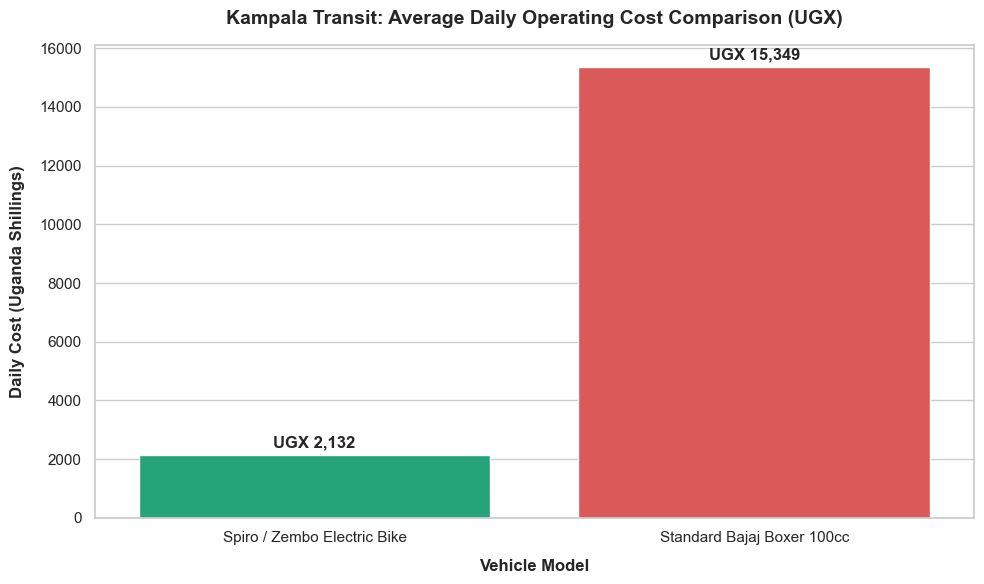

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Fix warning by assigning hue explicitly
ax = sns.barplot(
    x='model_name', 
    y='daily_cost_ugx', 
    hue='model_name',
    data=summary, 
    palette=['#10b981', '#ef4444'],
    legend=False
)

# Customize titles and labels
plt.title("Kampala Transit: Average Daily Operating Cost Comparison (UGX)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Vehicle Model", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Daily Cost (Uganda Shillings)", fontsize=12, fontweight='bold', labelpad=10)

# Correct string formatting for the bar numbers
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'UGX {height:,.0f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontweight='bold')

plt.tight_layout()
plt.show()
